In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

In [ ]:
path = "/content/drive/MyDrive/AnteproyectoTerminal/Código/evaluacionSistema.csv"

In [ ]:
df = pd.read_csv(path)

df.columns = ['timestamp', 'genero', 'edad', 'genero_musical', 'frecuencia', 'usa_streaming', 'prueba1', 'prueba2', 'conocimiento_genero']

In [ ]:
df

,timestamp,genero,edad,genero_musical,frecuencia,usa_streaming,prueba1,prueba2,conocimiento_genero
0,2026/04/22 7:02:50 p.m. GMT-6,Masculino,26 - 35 años,Clásica,"1-3h, más de 3h",Sí,Opción 2,Opción 1,Es uno de mis géneros favoritos.
1,2026/04/22 7:04:33 p.m. GMT-6,Femenino,26 - 35 años,Pop,"1-3h, más de 3h",Sí,Opción 1,Opción 2,Lo escucho ocasionalmente.
2,2026/04/22 7:06:44 p.m. GMT-6,Masculino,26 - 35 años,Instrumental,Más de 3h,Sí,Opción 1,Opción 1,Lo escucho ocasionalmente.
3,2026/04/22 7:13:52 p.m. GMT-6,Masculino,26 - 35 años,Rock,"1-3h, más de 3h",Sí,Opción 1,Opción 2,Lo escucho ocasionalmente.
4,2026/04/22 7:15:58 p.m. GMT-6,Femenino,26 - 35 años,Pop,"1-3h, más de 3h",Sí,Opción 1,Opción 2,Lo escucho ocasionalmente.
5,2026/04/22 7:32:49 p.m. GMT-6,Femenino,26 - 35 años,Rock,Más de 3h,Sí,Opción 1,Opción 2,Es uno de mis géneros favoritos.
6,2026/04/22 7:34:32 p.m. GMT-6,Femenino,26 - 35 años,Pop,Menos de 1h,Sí,Opción 1,Opción 2,No lo conozco / No me gusta.
7,2026/04/22 7:46:29 p.m. GMT-6,Masculino,26 - 35 años,Clásica,Más de 3h,No,Opción 1,Opción 2,No lo conozco / No me gusta.
8,2026/04/22 7:49:45 p.m. GMT-6,Masculino,26 - 35 años,Rock,"1-3h, más de 3h",Sí,Opción 2,Opción 2,Lo escucho ocasionalmente.
9,2026/04/22 7:50:30 p.m. GMT-6,Femenino,26 - 35 años,Pop,Más de 3h,Sí,Opción 2,Opción 1,No lo conozco / No me gusta.


In [ ]:
def calcular_aciertos(row):
    # En la Prueba 1, el modelo es la Opción 1
    acierto_p1 = 1 if row['prueba1'] == 'Opción 1' else 0

    # En la Prueba 2, el modelo es la Opción 2
    acierto_p2 = 1 if row['prueba2'] == 'Opción 2' else 0

    return pd.Series([acierto_p1, acierto_p2])

In [ ]:
df[['exito_p1', 'exito_p2']] = df.apply(calcular_aciertos, axis=1)

In [ ]:
total_pruebas = len(df) * 2  # 36 sujetos x 2 pruebas cada uno = 72 evaluaciones
total_aciertos = df['exito_p1'].sum() + df['exito_p2'].sum()
tasa_exito_global = (total_aciertos / total_pruebas) * 100

print(f"Total de evaluaciones: {total_pruebas}")
print(f"Total de aciertos del modelo: {total_aciertos}")
print(f"Tasa de éxito global: {tasa_exito_global:.2f}%")

Total de evaluaciones: 72
Total de aciertos del modelo: 47
Tasa de éxito global: 65.28%


<Figure size 1000x600 with 0 Axes>

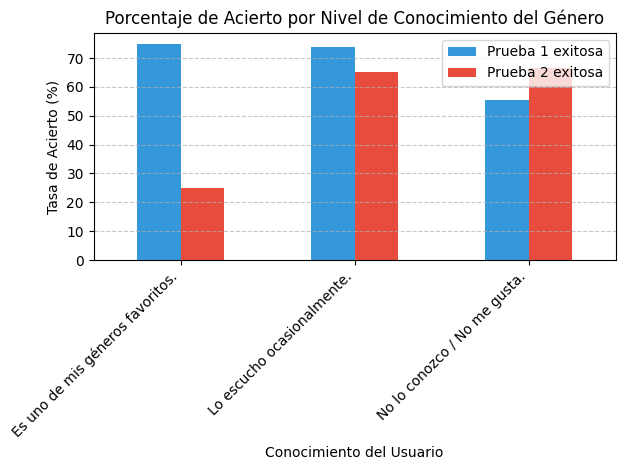

In [ ]:
analisis_conocimiento = df.groupby('conocimiento_genero')[['exito_p1', 'exito_p2']].mean() * 100

plt.figure(figsize=(10, 6))
analisis_conocimiento.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Porcentaje de Acierto por Nivel de Conocimiento del Género')
plt.ylabel('Tasa de Acierto (%)')
plt.xlabel('Conocimiento del Usuario')
plt.xticks(rotation=45, ha='right')
plt.legend(['Prueba 1 exitosa', 'Prueba 2 exitosa'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('conocimiento_vs_acierto.png')
plt.show()

/tmp/ipykernel_31073/292772013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='edad', y='aciertos_totales', data=df, palette='Set2')


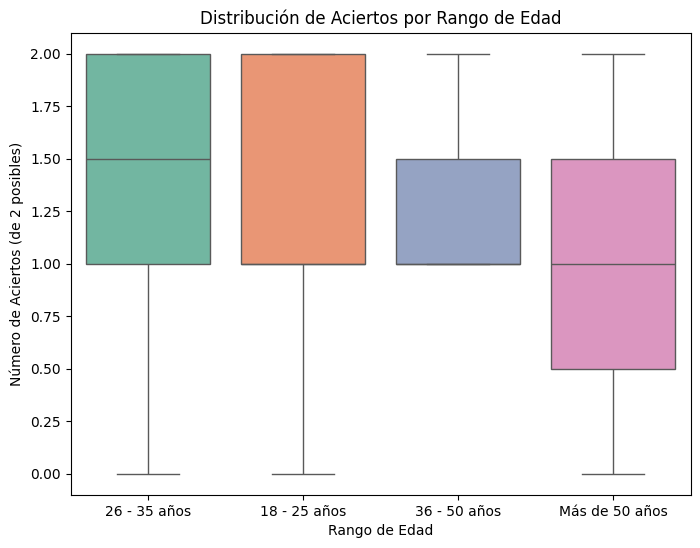

In [ ]:
df['aciertos_totales'] = df['exito_p1'] + df['exito_p2']
plt.figure(figsize=(8, 6))
sns.boxplot(x='edad', y='aciertos_totales', data=df, palette='Set2')
plt.title('Distribución de Aciertos por Rango de Edad')
plt.ylabel('Número de Aciertos (de 2 posibles)')
plt.xlabel('Rango de Edad')
plt.savefig('segmentacion_edad.png')
plt.show()

In [ ]:
# --- ANÁLISIS 3: Prueba Binomial de Significancia ---
# Total de intentos: 36 personas * 2 pruebas = 72
n_total = len(df) * 2
k_total = df['exito_p1'].sum() + df['exito_p2'].sum()

# Calculamos el P-Value (H0: El acierto es por azar, p=0.5)
p_val = binomtest(total_aciertos, n=total_pruebas, p=0.5, alternative='greater')

print("-" * 30)
print(f"RESUMEN ESTADÍSTICO")
print(f"Total de evaluaciones: {total_pruebas}")
print(f"Total de aciertos: {total_aciertos}")
print(f"Tasa de éxito global: {(total_aciertos/total_pruebas)*100:.2f}%")
print(f"P-Value: {p_val.pvalue:.5f}")
print("-" * 30)

if p_val.pvalue < 0.05:
    print("CONCLUSIÓN: El modelo es ESTADÍSTICAMENTE SIGNIFICATIVO.")
    print("La probabilidad de obtener estos resultados por azar es casi nula.")
else:
    print("CONCLUSIÓN: No hay evidencia suficiente para descartar el azar.")

------------------------------
RESUMEN ESTADÍSTICO
Total de evaluaciones: 72
Total de aciertos: 47
Tasa de éxito global: 65.28%
P-Value: 0.00639
------------------------------
CONCLUSIÓN: El modelo es ESTADÍSTICAMENTE SIGNIFICATIVO.
La probabilidad de obtener estos resultados por azar es casi nula.


/tmp/ipykernel_31070/3330622369.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='frecuencia', ax=ax1[1], palette='viridis')
/tmp/ipykernel_31070/3330622369.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='genero', ax=ax1[2], palette='magma')


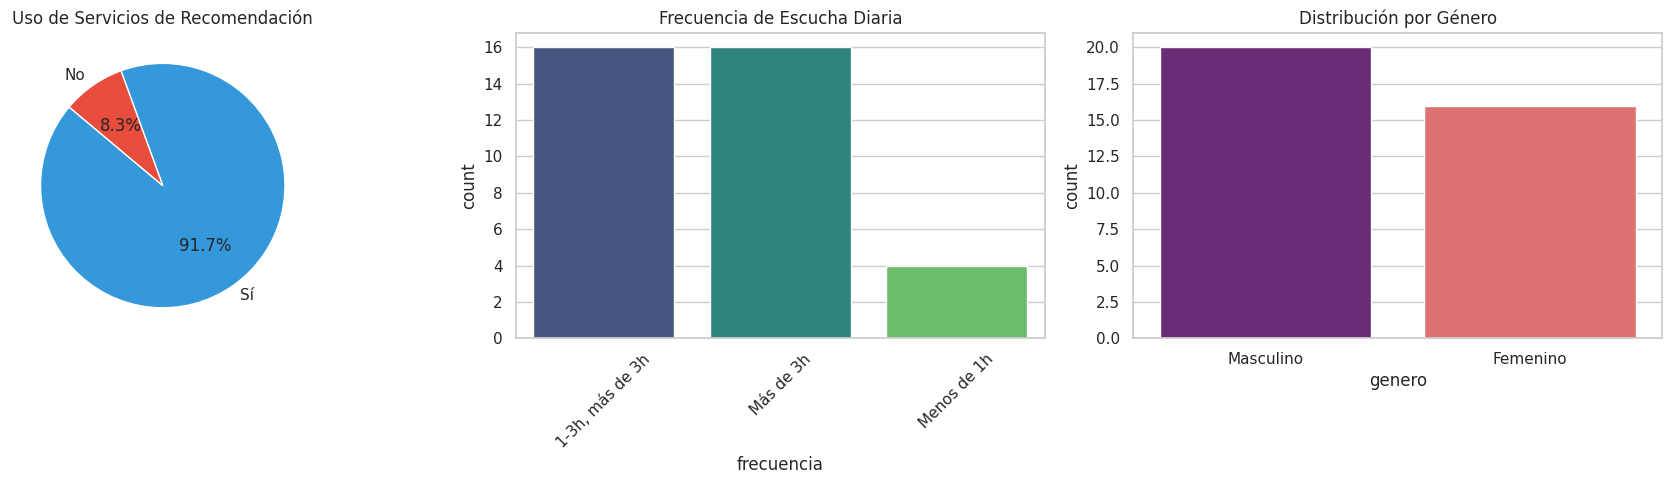

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# FIGURA 1: Perfil de Usuario y Hábitos (Combinada)
fig1, ax1 = plt.subplots(1, 3, figsize=(18, 5))

# A. Uso de Streaming
streaming_data = df['usa_streaming'].value_counts()
ax1[0].pie(streaming_data, labels=streaming_data.index, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=140)
ax1[0].set_title('Uso de Servicios de Recomendación')

# B. Frecuencia de Escucha
sns.countplot(data=df, x='frecuencia', ax=ax1[1], palette='viridis')
ax1[1].set_title('Frecuencia de Escucha Diaria')
ax1[1].tick_params(axis='x', rotation=45)

# C. Distribución por Género
sns.countplot(data=df, x='genero', ax=ax1[2], palette='magma')
ax1[2].set_title('Distribución por Género')

plt.tight_layout()
plt.savefig('perfil_usuario_habitos.png')
plt.show()